# CORS Records — Music Analysis Pipeline v4
Run cells top to bottom. Outputs go to `./output/`.

**Stages:**
1. Config
2. Feature extraction (librosa + Essentia key/BPM)
3. Essentia embeddings
4. Semantic mapping + tags + scale tiers
5. Combine → StandardScaler → PCA (librosa only)
6. Cosine similarity
7. K-means clustering + dendrogram
8. UMAP
9. Interactive UMAP plot
10. Annotation tool
11. SVR supervised layer
12. Summary

> **If re-running on existing data:** delete `output/features.csv` to force fresh extraction.

In [166]:
import os
from pathlib import Path

# ── Set your tracks folder ────────────────────────────────────────────────────
TRACKS_DIR = '/Users/maxbalateu/desktop/DATASET THESIS'   # ← change if needed

OUTPUT_DIR = Path('./output')
OUTPUT_DIR.mkdir(exist_ok=True)

def out(filename):
    """Returns full path to an output file."""
    return str(OUTPUT_DIR / filename)

assert Path(TRACKS_DIR).exists(), f'TRACKS_DIR not found: {TRACKS_DIR}'
audio_files = (list(Path(TRACKS_DIR).rglob('*.mp3')) +
               list(Path(TRACKS_DIR).rglob('*.MP3')) +
               list(Path(TRACKS_DIR).rglob('*.wav')) +
               list(Path(TRACKS_DIR).rglob('*.WAV')))
print(f'Found {len(audio_files)} audio files in {TRACKS_DIR}')
print(f'Outputs will be saved to: {OUTPUT_DIR.resolve()}')


Found 392 audio files in /Users/maxbalateu/desktop/DATASET THESIS
Outputs will be saved to: /Users/maxbalateu/Desktop/output


---
## Stage 1 — Feature extraction
Single pass per track. Delete `output/features.csv` to force full re-extraction.

In [167]:
from __future__ import annotations
import warnings
from pathlib import Path
import librosa
import numpy as np
import pandas as pd
import essentia.standard as es
from scipy.signal import butter, filtfilt
from tqdm import tqdm
warnings.filterwarnings('ignore', category=UserWarning)

WINDOW_START_S = 70.0
WINDOW_DUR_S   = 45.0
N_MFCC         = 13
N_FFT          = 2048
HOP_LENGTH     = 512
N_CONTRAST     = 7
LOW_FREQ_HZ    = 200

KEY_NAMES = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']
CAMELOT = {
    ('C','major'):'8B',  ('A','minor'):'8A',
    ('G','major'):'9B',  ('E','minor'):'9A',
    ('D','major'):'10B', ('B','minor'):'10A',
    ('A','major'):'11B', ('F#','minor'):'11A',
    ('E','major'):'12B', ('C#','minor'):'12A',
    ('B','major'):'1B',  ('G#','minor'):'1A',
    ('F#','major'):'2B', ('D#','minor'):'2A',
    ('C#','major'):'3B', ('A#','minor'):'3A',
    ('G#','major'):'4B', ('F','minor'):'4A',
    ('D#','major'):'5B', ('C','minor'):'5A',
    ('A#','major'):'6B', ('G','minor'):'6A',
    ('F','major'):'7B',  ('D','minor'):'7A',
}

def _trim_window(y, sr):
    start = int(WINDOW_START_S * sr)
    end   = int((WINDOW_START_S + WINDOW_DUR_S) * sr)
    if start >= len(y): start = 0
    end = min(end, len(y))
    return y[start:end], len(y[start:end]) / sr

def _spectral_spread(S, sr):
    freqs    = librosa.fft_frequencies(sr=sr, n_fft=N_FFT)
    centroid = librosa.feature.spectral_centroid(S=S, sr=sr)[0]
    mag_sum  = S.sum(axis=0) + 1e-10
    return np.sqrt(np.sum((freqs[:,None] - centroid[None,:])**2 * S, axis=0) / mag_sum)

def _spectral_flux(S):
    diff = np.diff(S, axis=1)
    return np.sqrt((diff**2).sum(axis=0))

def _peak_durations(y, sr):
    onsets = librosa.onset.onset_detect(y=y, sr=sr, hop_length=HOP_LENGTH, backtrack=True)
    if len(onsets) < 2: return 0.0, 0.0
    times = librosa.frames_to_time(onsets, sr=sr, hop_length=HOP_LENGTH)
    ivl   = np.diff(times)
    return float(ivl.mean()), float(ivl.var())

def _low_freq_ratio(S, sr):
    freqs   = librosa.fft_frequencies(sr=sr, n_fft=N_FFT)
    low_idx = np.searchsorted(freqs, LOW_FREQ_HZ)
    total   = S.sum() + 1e-10
    return float(S[:low_idx].sum() / total)

def _lowpass_filter(y, sr, cutoff=200):
    nyq = sr / 2
    b, a = butter(4, cutoff / nyq, btype='low')
    return filtfilt(b, a, y)

def extract_features(filepath):
    y, sr             = librosa.load(str(filepath), sr=None, mono=True)
    y_win, actual_dur = _trim_window(y, sr)
    S                 = np.abs(librosa.stft(y_win, n_fft=N_FFT, hop_length=HOP_LENGTH))

    # MFCCs
    mfccs    = librosa.feature.mfcc(y=y_win, sr=sr, n_mfcc=N_MFCC,
                                     n_fft=N_FFT, hop_length=HOP_LENGTH)
    # spectral
    centroid = librosa.feature.spectral_centroid(S=S, sr=sr)[0]
    flatness = librosa.feature.spectral_flatness(S=S)[0]
    spread   = _spectral_spread(S, sr)
    flux     = _spectral_flux(S)
    zcr      = librosa.feature.zero_crossing_rate(y_win, hop_length=HOP_LENGTH)[0]
    rms      = librosa.feature.rms(y=y_win, hop_length=HOP_LENGTH)[0]

    # tempo anchored to techno range
    tempo_arr, beat_frames = librosa.beat.beat_track(
        y=y_win, sr=sr, hop_length=HOP_LENGTH, start_bpm=130, tightness=100)
    tempo = float(np.atleast_1d(tempo_arr)[0])
    while tempo < 110: tempo *= 2
    while tempo > 160: tempo /= 2
    beat_count            = int(len(beat_frames))
    peak_dur_mean, peak_dur_var = _peak_durations(y_win, sr)

    # ── rhythm pattern: 4/4 vs broken ──
    if len(beat_frames) >= 4:
        beat_times = librosa.frames_to_time(beat_frames, sr=sr, hop_length=HOP_LENGTH)
        ibi        = np.diff(beat_times)
        ibi_mean   = float(ibi.mean())
        ibi_cv     = float(ibi.std() / (ibi_mean + 1e-10))
    else:
        ibi_mean   = 0.0
        ibi_cv     = 0.0

    # chromagram
    chroma           = librosa.feature.chroma_cqt(y=y_win, sr=sr, hop_length=HOP_LENGTH)
    chroma_per_class = chroma.mean(axis=1)
    chroma_mean      = float(chroma.mean())
    chroma_std       = float(chroma.std())
    chroma_energy    = float((chroma**2).mean())
    p                = chroma_per_class / (chroma_per_class.sum() + 1e-10)
    chroma_entropy   = float(-np.sum(p * np.log2(p + 1e-10)))

    # spectral contrast
    contrast      = librosa.feature.spectral_contrast(
        S=S, sr=sr, n_bands=N_CONTRAST - 1, hop_length=HOP_LENGTH)
    contrast_mean = contrast.mean(axis=1)
    contrast_std  = contrast.std(axis=1)

    # low-frequency energy ratio
    low_freq_ratio = _low_freq_ratio(S, sr)

    # onset strength — low frequency only with threshold
    y_low            = _lowpass_filter(y_win, sr, cutoff=200).astype(np.float32)
    onset_env        = librosa.onset.onset_strength(y=y_low, sr=sr, hop_length=HOP_LENGTH)
    ONSET_THRESHOLD  = np.percentile(onset_env, 75)
    onset_env_thresh = np.where(onset_env > ONSET_THRESHOLD, onset_env, 0.0)
    onset_mean       = float(onset_env_thresh.mean())
    onset_std        = float(onset_env_thresh.std())
    onset_max        = float(onset_env_thresh.max())
    onset_sharpness  = onset_mean * (onset_mean / (onset_std + 1e-10))

    # ── ambient detection — override rhythm features if no clear beat ──
    beats_per_second = beat_count / max(actual_dur, 1)
    is_ambient = (
        onset_mean < 0.05
        or beats_per_second < 0.5
        or float(rms.std()) < 0.01
    )
    if is_ambient:
        onset_sharpness = 0.0
        onset_mean      = 0.0
        beat_count      = 0
        peak_dur_mean   = 0.0
        peak_dur_var    = 0.0


    # key detection via Essentia
    key_extractor       = es.KeyExtractor()
    y_key               = librosa.resample(y_win, orig_sr=sr, target_sr=44100) if sr != 44100 else y_win
    key, scale, key_str = key_extractor(y_key.astype('float32'))

    # assemble
    feats = {}
    for i in range(N_MFCC):
        feats[f'mfcc_mean_{i}'] = float(mfccs[i].mean())
        feats[f'mfcc_std_{i}']  = float(mfccs[i].std())
    feats['spectral_centroid_mean'] = float(centroid.mean())
    feats['spectral_centroid_std']  = float(centroid.std())
    feats['spectral_flatness_mean'] = float(flatness.mean())
    feats['spectral_flatness_std']  = float(flatness.std())
    feats['spectral_spread_mean']   = float(spread.mean())
    feats['spectral_spread_std']    = float(spread.std())
    feats['spectral_flux_mean']     = float(flux.mean())
    feats['spectral_flux_std']      = float(flux.std())
    feats['zcr_mean']               = float(zcr.mean())
    feats['zcr_std']                = float(zcr.std())
    feats['rms_mean']               = float(rms.mean())
    feats['rms_std']                = float(rms.std())
    feats['tempo']                  = tempo
    feats['beat_count']             = beat_count
    feats['peak_dur_mean']          = peak_dur_mean
    feats['peak_dur_var']           = peak_dur_var
    feats['ibi_mean']               = ibi_mean
    feats['ibi_cv']            = ibi_cv
    feats['actual_window_dur']      = actual_dur
    feats['chroma_mean']            = chroma_mean
    feats['chroma_std']             = chroma_std
    feats['chroma_energy']          = chroma_energy
    feats['chroma_entropy']         = chroma_entropy
    for i, v in enumerate(chroma_per_class):
        feats[f'chroma_class_{i}']  = float(v)
    for i in range(N_CONTRAST):
        feats[f'contrast_mean_{i}'] = float(contrast_mean[i])
        feats[f'contrast_std_{i}']  = float(contrast_std[i])
    feats['low_freq_ratio']         = low_freq_ratio
    feats['onset_mean']             = onset_mean
    feats['onset_std']              = onset_std
    feats['onset_max']              = onset_max
    feats['onset_sharpness']        = onset_sharpness
    feats['key']                    = key
    feats['scale']                  = scale
    feats['key_strength']           = float(key_str)
    feats['key_idx']                = KEY_NAMES.index(key) if key in KEY_NAMES else -1
    feats['camelot']                = CAMELOT.get((key, scale), '?')
    feats['is_ambient']             = 1.0 if is_ambient else 0.0
    return feats


def run_extraction(wav_folder, output_path='features.csv', checkpoint_every=50):
    wav_folder = Path(wav_folder)
    wav_files  = (sorted(wav_folder.rglob('*.mp3')) + sorted(wav_folder.rglob('*.MP3')) +
                  sorted(wav_folder.rglob('*.wav')) + sorted(wav_folder.rglob('*.WAV')))
    wav_files  = list(dict.fromkeys(wav_files))
    if not wav_files:
        raise FileNotFoundError(f'No audio files found in {wav_folder}')

    seen, dupes = {}, []
    for fp in wav_files:
        stem = fp.stem.lower()
        if stem in seen: dupes.append((fp, seen[stem]))
        else: seen[stem] = fp
    if dupes:
        print(f'\n⚠️  {len(dupes)} duplicate(s):')
        for d, o in dupes: print(f'   DUP  {d.name}  ←  {o.name}')
    wav_files = list(dict.fromkeys(wav_files))

    already_done = set()
    if Path(output_path).exists():
        existing     = pd.read_csv(output_path)
        already_done = set(existing['track_id'].tolist())
        records      = existing.to_dict('records')
        print(f'Resuming — {len(already_done)} done, {len(wav_files)-len(already_done)} remaining')
    else:
        records = []

    pending = [fp for fp in wav_files if fp.stem not in already_done]
    errors  = []
    for idx, fp in enumerate(tqdm(pending, desc='Extracting', unit='track')):
        try:
            feats             = extract_features(fp)
            feats['track_id'] = fp.stem
            feats['filepath'] = str(fp)
            records.append(feats)
        except Exception as exc:
            errors.append(str(exc))
            tqdm.write(f'  [WARN] skipped {fp.name}: {exc}')
        if (idx + 1) % checkpoint_every == 0:
            pd.DataFrame(records).to_csv(output_path, index=False)
            tqdm.write(f'  [checkpoint] {len(records)} saved')

    df        = pd.DataFrame(records)
    id_cols   = ['track_id', 'filepath']
    feat_cols = [c for c in df.columns if c not in id_cols]
    df        = df[id_cols + feat_cols]
    df.to_csv(output_path, index=False)
    print(f'\nSaved {len(df)} tracks → {output_path}')
    if errors: print(f'{len(errors)} error(s).')
    return df

print('Feature extraction functions loaded.')

Feature extraction functions loaded.


In [168]:
df_features = run_extraction(
    wav_folder  = TRACKS_DIR,
    output_path = out('features.csv'),
)

# verify all expected columns are present
expected = ['chroma_entropy', 'low_freq_ratio', 'onset_sharpness', 'contrast_mean_0', 'ibi_cv', 'ibi_mean']
print('\nColumn check:')
for col in expected:
    status = '✓' if col in df_features.columns else '✗ MISSING — delete output/features.csv and re-extract'
    print(f'  {status}  {col}')

print(f'\nShape: {df_features.shape}')
df_features.head(3)

import subprocess
result = subprocess.run(['find', '/Users/maxbalateu', '-name', 'features.csv', '-not', '-path', '*/.*'], 
                       capture_output=True, text=True)
print(result.stdout)



⚠️  1 duplicate(s):
   DUP  Max Balateu - Stripped Lights .wav  ←  Max Balateu - Stripped Lights .mp3


Extracting:  13%|█▎        | 50/392 [00:50<04:57,  1.15track/s]

  [checkpoint] 50 saved


Extracting:  22%|██▏       | 87/392 [01:27<04:49,  1.05track/s]Note: Illegal Audio-MPEG-Header 0xcb1df904 at offset 12108461.
Note: Trying to resync...
Note: Skipped 149 bytes in input.
Extracting:  24%|██▍       | 95/392 [01:34<04:36,  1.07track/s][src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!
Note: Illegal Audio-MPEG-Header 0x00000000 at offset 8389579.
Note: Trying to resync...
Note: Skipped 1024 bytes in input.
[src/libmpg123/parse.c:wetwork():1349] error: Giving up resync after 1024 bytes - your stream is not nice... (maybe increasing resync limit could help).
/opt/homebrew/Caskroom/miniforge/base/envs/cors/lib/python3.10/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Extracting:  26%|██▌       | 100/392 [01:39<04:59,  1.02s/track]

  [checkpoint] 100 saved


...

  [checkpoint] 300 saved


Extracting:  89%|████████▉ | 350/392 [05:44<00:39,  1.06track/s]

  [checkpoint] 350 saved


Extracting: 100%|██████████| 392/392 [06:27<00:00,  1.01track/s]



Saved 392 tracks → output/features.csv

Column check:
  ✓  chroma_entropy
  ✓  low_freq_ratio
  ✓  onset_sharpness
  ✓  contrast_mean_0
  ✓  ibi_cv
  ✓  ibi_mean

Shape: (392, 88)
/Users/maxbalateu/Desktop/Thesis - File/features.csv
/Users/maxbalateu/Desktop/output/features.csv



In [169]:
# ── De-duplicate entries ──────────────────────────────────────────────────────
before = len(df_features)
df_features = df_features.drop_duplicates(subset='track_id', keep='last').reset_index(drop=True)
removed = before - len(df_features)
print(f'Removed {removed} duplicate(s). {len(df_features)} tracks remaining.')

Removed 1 duplicate(s). 391 tracks remaining.


In [170]:
print("low_freq_ratio in df_features:", 'low_freq_ratio' in df_features.columns)
print("onset_sharpness in df_features:", 'onset_sharpness' in df_features.columns)
print("chroma_entropy in df_features:", 'chroma_entropy' in df_features.columns)
print()
print("All columns:", [c for c in df_features.columns])

low_freq_ratio in df_features: True
onset_sharpness in df_features: True
chroma_entropy in df_features: True

All columns: ['track_id', 'filepath', 'mfcc_mean_0', 'mfcc_std_0', 'mfcc_mean_1', 'mfcc_std_1', 'mfcc_mean_2', 'mfcc_std_2', 'mfcc_mean_3', 'mfcc_std_3', 'mfcc_mean_4', 'mfcc_std_4', 'mfcc_mean_5', 'mfcc_std_5', 'mfcc_mean_6', 'mfcc_std_6', 'mfcc_mean_7', 'mfcc_std_7', 'mfcc_mean_8', 'mfcc_std_8', 'mfcc_mean_9', 'mfcc_std_9', 'mfcc_mean_10', 'mfcc_std_10', 'mfcc_mean_11', 'mfcc_std_11', 'mfcc_mean_12', 'mfcc_std_12', 'spectral_centroid_mean', 'spectral_centroid_std', 'spectral_flatness_mean', 'spectral_flatness_std', 'spectral_spread_mean', 'spectral_spread_std', 'spectral_flux_mean', 'spectral_flux_std', 'zcr_mean', 'zcr_std', 'rms_mean', 'rms_std', 'tempo', 'beat_count', 'peak_dur_mean', 'peak_dur_var', 'ibi_mean', 'ibi_cv', 'actual_window_dur', 'chroma_mean', 'chroma_std', 'chroma_energy', 'chroma_entropy', 'chroma_class_0', 'chroma_class_1', 'chroma_class_2', 'chroma_class_

---
## Stage 2 — Essentia embeddings
Produces a ~35-dim tonal/rhythmic/timbral vector per track.
Used for display and search only — not included in PCA/clustering.

In [171]:
import essentia.standard as es
import numpy as np
import pandas as pd
from tqdm import tqdm

def get_essentia_embedding(filepath):
    loader = es.MonoLoader(filename=str(filepath), sampleRate=44100)
    audio  = loader()
    start  = int(15 * 44100)
    end    = int(45 * 44100)
    if start >= len(audio): start = 0
    audio  = audio[start:min(end, len(audio))]

    key_ext             = es.KeyExtractor()
    key, scale, strength = key_ext(audio)
    rhythm_ext          = es.RhythmExtractor2013(method='multifeature')
    bpm, beats, bpm_conf, _, beat_ints = rhythm_ext(audio)

    w, spec   = es.Windowing(type='hann'), es.Spectrum()
    mfcc_es   = es.MFCC(numberCoefficients=13)
    sc        = es.SpectralCentroidTime()
    rolloff   = es.RollOff()
    flux_es   = es.Flux()
    zcr_es    = es.ZeroCrossingRate()

    mfcc_frames, centroid_f, rolloff_f, flux_f, zcr_f = [], [], [], [], []
    for frame in es.FrameGenerator(audio, frameSize=2048, hopSize=512):
        windowed = w(frame)
        spectrum = spec(windowed)
        _, mfcc_coeffs = mfcc_es(spectrum)
        mfcc_frames.append(mfcc_coeffs)
        centroid_f.append(sc(frame))
        rolloff_f.append(rolloff(spectrum))
        flux_f.append(flux_es(spectrum))
        zcr_f.append(zcr_es(frame))

    mfcc_arr = np.array(mfcc_frames)
    vec = np.concatenate([
        mfcc_arr.mean(axis=0), mfcc_arr.std(axis=0),
        [np.mean(centroid_f), np.std(centroid_f)],
        [np.mean(rolloff_f)], [np.mean(flux_f)], [np.mean(zcr_f)],
        [float(bpm), float(bpm_conf), float(strength)],
        [float(scale == 'major')],
    ])
    return vec.astype(np.float32)

embeddings, failed = [], []
for tid, fp in tqdm(zip(df_features['track_id'], df_features['filepath']),
                    total=len(df_features), desc='Essentia', unit='track'):
    try:
        emb = get_essentia_embedding(fp)
        embeddings.append({'track_id': tid,
                           **{f'eff_{i}': v for i, v in enumerate(emb)}})
    except Exception as exc:
        failed.append(tid)
        tqdm.write(f'  [WARN] {tid}: {exc}')

df_ess = pd.DataFrame(embeddings)
df_ess.to_csv(out('essentia_embeddings.csv'), index=False)
print(f'Done. {len(df_ess)} embedded, {len(failed)} failed.')


Essentia:  22%|██▏       | 87/391 [01:21<04:16,  1.18track/s][ WARNING  ] AudioLoader: invalid frame, skipping it: Invalid data found when processing input
[ WARNING  ] AudioLoader: invalid frame, skipping it: Invalid data found when processing input
Essentia:  76%|███████▌  | 297/391 [04:18<01:18,  1.20track/s][ WARNING  ] AudioLoader: invalid frame, skipping it: Invalid data found when processing input
[ WARNING  ] AudioLoader: invalid frame, skipping it: Invalid data found when processing input
Essentia:  94%|█████████▍| 368/391 [05:18<00:18,  1.26track/s][ WARNING  ] AudioLoader: invalid frame, skipping it: Invalid data found when processing input
[ WARNING  ] AudioLoader: invalid frame, skipping it: Invalid data found when processing input
Essentia: 100%|██████████| 391/391 [05:40<00:00,  1.15track/s]

Done. 391 embedded, 0 failed.


---
## Stage 3 — Semantic mapping + tags + scale tiers

In [172]:
import numpy as np
import pandas as pd

def _softscale(s: pd.Series) -> pd.Series:
    mu, sigma = s.mean(), s.std()
    if sigma < 1e-10:
        return pd.Series(np.full(len(s), 0.5), index=s.index)
    z = (s - mu) / (3 * sigma)
    return ((z + 1) / 2).clip(0, 1)

def add_semantic_descriptors(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # ── core descriptors ──
    df['brightness']      = _softscale(df['spectral_centroid_mean'])
    df['compactness']     = _softscale(1.0 / (df['spectral_spread_mean'] + 1e-10))
    df['density']         = _softscale(
        _softscale(df['rms_mean']) + _softscale(df['mfcc_mean_0'])
    )
    bps                   = df['beat_count'] / df['actual_window_dur'].clip(lower=1e-3)
    df['rhythm_strength'] = _softscale(bps)

    # ── new descriptors replacing roughness ──
    # texture: average spectral contrast across bands
    # high = clear frequency separation (kick/pad/hihat distinct)
    # low  = blurred/homogeneous frequency content
    contrast_cols = [f'contrast_mean_{i}' for i in range(7)
                     if f'contrast_mean_{i}' in df.columns]
    if contrast_cols:
        df['texture'] = _softscale(df[contrast_cols].mean(axis=1))

    # warmth: dark + bassy = warm analogue feel; bright + trebly = cold
    if 'low_freq_ratio' in df.columns:
        df['warmth'] = _softscale(
            _softscale(-df['spectral_centroid_mean']) +
            _softscale(df['low_freq_ratio'])
        )

    # ── conditional descriptors ──
    if 'chroma_entropy' in df.columns:
        df['tonality']    = _softscale(-df['chroma_entropy'])
    # punch = consistently strong onset energy = true percussive hardness
    if 'onset_sharpness' in df.columns:
            df['punch'] = _softscale(df['onset_sharpness'])
    if 'low_freq_ratio' in df.columns:
        df['bass_weight'] = _softscale(df['low_freq_ratio'])

    return df


# ── descriptor list (used throughout) ──
DESCRIPTORS = [
    'brightness', 'compactness', 'density', 'rhythm_strength',
    'texture', 'warmth', 'tonality', 'punch', 'bass_weight', 'groove_regularity',
]

TAGS = {
    # single-descriptor tags
    'bright'      : lambda r: r.get('brightness', 0)      > 0.60,
    'dark'        : lambda r: r.get('brightness', 1)      < 0.40,
    'punchy'      : lambda r: r.get('punch', 0)            > 0.60,
    'soft'        : lambda r: r.get('punch', 1)            < 0.40,
    'tonal'       : lambda r: r.get('tonality', 0)         > 0.60,
    'atonal'      : lambda r: r.get('tonality', 1)         < 0.40,
    'bass_heavy'  : lambda r: r.get('bass_weight', 0)      > 0.60,
    'minimal'     : lambda r: r.get('density', 1)          < 0.40,
    'dense'       : lambda r: r.get('density', 0)          > 0.60,
    'rhythmic'    : lambda r: r.get('rhythm_strength', 0)  > 0.60,
    'warm'        : lambda r: r.get('warmth', 0)           > 0.60,
    'cold'        : lambda r: r.get('warmth', 1)           < 0.40,
    'textured'    : lambda r: r.get('texture', 0)          > 0.60,
    'flat'        : lambda r: r.get('texture', 1)          < 0.40,
    'ambient'     : lambda r: r.get('is_ambient', 0)       == 1.0,
    'four_four': lambda r: r.get('groove_regularity', 0) > 0.60
                    and r.get('beat_count', 0) > 20,

    'broken'   : lambda r: r.get('ibi_cv', 0) >= 0.085
                    and r.get('beat_count', 0) > 20
                    and r.get('is_ambient', 0) == 0.0,

    # compound curatorial tags — acoustic + BPM
    'heavy_club'  : lambda r: r.get('bass_weight', 0)      > 0.60
                           and r.get('punch', 0)            > 0.55
                           and r.get('tempo', 0)            > 133,

    'dub_techno'  : lambda r: r.get('tonality', 0)         > 0.58
                           and r.get('bass_weight', 0)      > 0.50
                           and r.get('density', 1)          < 0.65
                           and r.get('tempo', 0)            < 136,

    'hardgroove'  : lambda r: r.get('punch', 0)            > 0.58
                           and r.get('rhythm_strength', 0)  > 0.55
                           and r.get('tonality', 1)         < 0.55
                           and r.get('tempo', 0)            > 137,

    'industrial'  : lambda r: r.get('texture', 0)          > 0.58
                           and r.get('brightness', 0)       > 0.50
                           and r.get('tonality', 1)         < 0.45
                           and r.get('tempo', 0)            > 132,

    'deep_minimal': lambda r: r.get('density', 1)          < 0.42
                           and r.get('bass_weight', 0)      > 0.45
                           and r.get('brightness', 1)       < 0.50
                           and r.get('tempo', 0)            < 130,

    'atmospheric' : lambda r: r.get('density', 0)          > 0.50
                           and r.get('punch', 1)            < 0.45
                           and r.get('warmth', 0)           > 0.45
                           and r.get('tempo', 0)            < 133,
}


def tag_corpus(df):
    df          = df.copy()
    tag_results = df.apply(
        lambda r: [t for t, fn in TAGS.items() if fn(r)], axis=1
    )
    df['tags']  = tag_results.apply(lambda t: ', '.join(t) if t else 'unclassified')
    for tag in TAGS:
        df[f'tag_{tag}'] = tag_results.apply(lambda t: tag in t)
    return df


def classify_scales(df):
    df = df.copy()
    for desc in DESCRIPTORS:
        if desc not in df.columns: continue
        df[f'{desc}_scale'] = pd.cut(
            df[desc],
            bins=[-0.01, 0.25, 0.45, 0.65, 0.80, 1.01],
            labels=['very low', 'low', 'medium', 'high', 'very high']
        ).astype(str)
    if 'tempo' in df.columns:
        df['bpm_tier'] = pd.cut(
            df['tempo'],
            bins=[0, 120, 128, 133, 138, 145, 200],
            labels=['slow', 'house', 'minimal', 'techno', 'hardgroove', 'fast']
        ).astype(str)
    return df
def add_semantic_descriptors(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['brightness']      = _softscale(df['spectral_centroid_mean'])
    df['compactness']     = _softscale(1.0 / (df['spectral_spread_mean'] + 1e-10))
    df['density']         = _softscale(
        _softscale(df['rms_mean']) + _softscale(df['mfcc_mean_0'])
    )
    bps                   = df['beat_count'] / df['actual_window_dur'].clip(lower=1e-3)
    df['rhythm_strength'] = _softscale(bps)
    if 'ibi_cv' in df.columns:
        df['groove_regularity'] = _softscale(-df['ibi_cv'])
    contrast_cols = [f'contrast_mean_{i}' for i in range(7)
                     if f'contrast_mean_{i}' in df.columns]
    if contrast_cols:
        df['texture'] = _softscale(df[contrast_cols].mean(axis=1))

    if 'low_freq_ratio' in df.columns:
        df['warmth'] = _softscale(
            _softscale(-df['spectral_centroid_mean']) +
            _softscale(df['low_freq_ratio'])
        )
    if 'chroma_entropy' in df.columns:
        df['tonality']    = _softscale(-df['chroma_entropy'])
    if 'onset_sharpness' in df.columns:
        df['punch']       = _softscale(df['onset_sharpness'])
    if 'low_freq_ratio' in df.columns:
        df['bass_weight'] = _softscale(df['low_freq_ratio'])

    # ── hard override for ambient tracks ──
    if 'is_ambient' in df.columns:
        ambient = df['is_ambient'] == 1.0
        df.loc[ambient, 'punch']          = 0.0
        df.loc[ambient, 'rhythm_strength'] = 0.0
        df.loc[ambient, 'bass_weight']    = df.loc[ambient, 'bass_weight'] * 0.3
        print(f'Ambient tracks detected: {ambient.sum()}')

    return df

print('Semantic mapping, tags, and scale tiers loaded.')


Semantic mapping, tags, and scale tiers loaded.


In [173]:
df_mapped = add_semantic_descriptors(df_features)

# ibi_cv corpus thresholds — check these after each fresh extraction
if 'ibi_cv' in df_mapped.columns:
    p25 = df_mapped['ibi_cv'].quantile(0.25)
    p75 = df_mapped['ibi_cv'].quantile(0.75)
    print(f'ibi_cv  p25={p25:.4f}  p75={p75:.4f}')
df_mapped = tag_corpus(df_mapped)
# apply manual tag overrides from app
from pathlib import Path
manual_path = out("manual_tags.csv")
if Path(manual_path).exists():
    manual_tags = pd.read_csv(manual_path)
    df_mapped   = df_mapped.merge(manual_tags[["track_id","manual_tags"]],
                                   on="track_id", how="left")
    mask = df_mapped["manual_tags"].notna()
    df_mapped.loc[mask, "tags"] = df_mapped.loc[mask, "manual_tags"]
    df_mapped.drop(columns=["manual_tags"], inplace=True)
    print(f"Applied {mask.sum()} manual tag overrides.")
df_mapped = classify_scales(df_mapped)

print('=== Descriptor statistics ===')
present_descs = [c for c in DESCRIPTORS if c in df_mapped.columns]
print(df_mapped[present_descs].describe().round(3))

print('\n=== Tag distribution ===')
tag_cols = [c for c in df_mapped.columns if c.startswith('tag_')]
for tc in sorted(tag_cols):
    n = df_mapped[tc].sum()
    if n > 0:
        print(f'  {tc.replace("tag_",""):20s}  {n:3d} tracks  ({100*n/len(df_mapped):.0f}%)')

print(f'\nUnclassified: {(df_mapped["tags"] == "unclassified").sum()} tracks')


Ambient tracks detected: 3
ibi_cv  p25=0.0113  p75=0.0292
=== Descriptor statistics ===
       brightness  compactness  density  rhythm_strength  texture   warmth  \
count     391.000      391.000  391.000          391.000  391.000  391.000   
mean        0.499        0.496    0.500            0.505    0.501    0.500   
std         0.163        0.145    0.166            0.143    0.159    0.167   
min         0.132        0.260    0.000            0.000    0.000    0.026   
25%         0.381        0.396    0.393            0.468    0.392    0.390   
50%         0.489        0.463    0.513            0.520    0.485    0.500   
75%         0.606        0.561    0.621            0.582    0.595    0.625   
max         1.000        1.000    0.851            1.000    1.000    0.906   

       tonality    punch  bass_weight  groove_regularity  
count   391.000  391.000      391.000            391.000  
mean      0.496    0.502        0.497              0.503  
std       0.149    0.156        

---
## Stage 4 — Combine → StandardScaler → PCA
Librosa features only go into PCA/clustering/similarity.
Essentia embeddings stay in `df_final` for display in the app.

Merged: 391 tracks, 168 columns
Librosa cols → PCA: 77
Essentia cols (display only): 35
PCA: 43 components → 95.1% variance
X_pca shape: (391, 43)


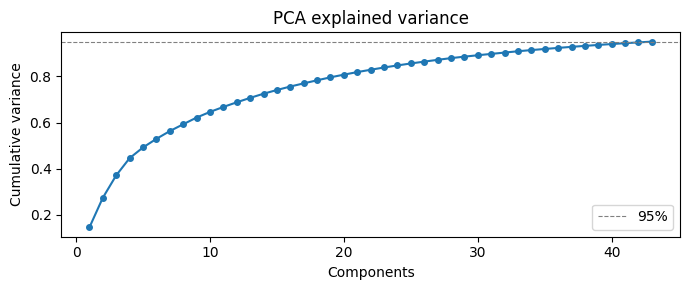

In [174]:
import joblib
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# merge librosa + essentia into one dataframe
df_final = df_mapped.merge(df_ess, on='track_id', how='inner')
print(f'Merged: {len(df_final)} tracks, {df_final.shape[1]} columns')

_NON_FEATURE = {
    'track_id', 'filepath', 'actual_window_dur', 'is_ambient',
    'ibi_mean', 'ibi_cv',
    'tags', 'key', 'scale', 'camelot', 'key_strength', 'key_idx', 'bpm_tier',
    'cluster', 'umap_x', 'umap_y',
}
_NON_FEATURE.update(DESCRIPTORS)
_NON_FEATURE.update([c for c in df_final.columns if c.endswith('_scale')])
_NON_FEATURE.update([c for c in df_final.columns if c.startswith('tag_')])
_NON_FEATURE.update([c for c in df_final.columns if c.startswith('eff_')])   # Essentia display only

librosa_cols = [
    c for c in df_final.columns
    if c not in _NON_FEATURE and df_final[c].dtype.kind in ('f', 'i')
]
essentia_cols = [c for c in df_final.columns if c.startswith('eff_')]
print(f'Librosa cols → PCA: {len(librosa_cols)}')
print(f'Essentia cols (display only): {len(essentia_cols)}')

X        = df_final[librosa_cols].values.astype(float)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca      = PCA(n_components=0.95, random_state=42)
X_pca    = pca.fit_transform(X_scaled)

joblib.dump(scaler, out('scaler.joblib'))
joblib.dump(pca,    out('pca.joblib'))
feature_cols = librosa_cols   # used by SVR cell

print(f'PCA: {pca.n_components_} components → {pca.explained_variance_ratio_.sum():.1%} variance')
print(f'X_pca shape: {X_pca.shape}')

cumvar = pca.explained_variance_ratio_.cumsum()
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(range(1, len(cumvar)+1), cumvar, marker='o', ms=4, lw=1.5)
ax.axhline(0.95, color='grey', lw=0.8, ls='--', label='95%')
ax.set_xlabel('Components'); ax.set_ylabel('Cumulative variance')
ax.set_title('PCA explained variance'); ax.legend()
plt.tight_layout()
plt.savefig(out('pca_variance.png'), dpi=150)
plt.show()


---
## Stage 5 — Cosine similarity matrix

In [175]:
from sklearn.metrics.pairwise import cosine_distances
import pandas as pd

dist_matrix = cosine_distances(X_pca)
np.save(out('distance_matrix.npy'), dist_matrix)
print(f'Distance matrix {dist_matrix.shape} saved.')

def get_similar(track_id, k=10):
    matches = df_final.index[df_final['track_id'] == track_id].tolist()
    if not matches: return pd.DataFrame()
    i        = matches[0]
    dists    = dist_matrix[i].copy()
    dists[i] = np.inf
    idx      = np.argsort(dists)[:k]
    result   = df_final.iloc[idx].copy()
    result['distance'] = dists[idx]
    keep = (['track_id', 'distance'] + [c for c in DESCRIPTORS if c in result.columns] +
            [c for c in ['tempo', 'key', 'camelot', 'tags'] if c in result.columns])
    return result[keep].reset_index(drop=True)

first = df_final['track_id'].iloc[0]
print(f'\n5 most similar to: {first}')
print(get_similar(first, k=5).to_string(index=False))


Distance matrix (391, 391) saved.

5 most similar to: 01 Balancer
                                                                               track_id  distance  brightness  compactness  density  rhythm_strength  texture   warmth  tonality    punch  bass_weight  groove_regularity      tempo key camelot                                               tags
                                        02-vinicius_honorio-haunted_loop_(original_mix)  0.370994    0.480873     0.457972 0.610787         0.478747 0.718054 0.520497  0.355469 0.507047     0.519513           0.612620 139.674831   D      7A                 atonal, dense, textured, four_four
                                                Vinicius Honorio - Stabbed In The Heart  0.394974    0.442523     0.476610 0.686778         0.489108 0.538560 0.505673  0.409198 0.483390     0.454033           0.592713 135.999178   B     10A                                              dense
                                                          

---
## Stage 6 — K-means clustering + hierarchical dendrogram

  k= 3  silhouette=0.0913
  k= 4  silhouette=0.0796
  k= 5  silhouette=0.0723
  k= 6  silhouette=0.0572
  k= 7  silhouette=0.0560
  k= 8  silhouette=0.0466
  k= 9  silhouette=0.0480
  k=10  silhouette=0.0547

Best k=3  silhouette=0.0913
Davies-Bouldin index (k=3): 2.502


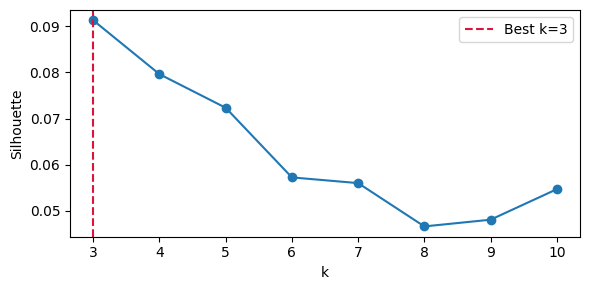

Computing Ward linkage...


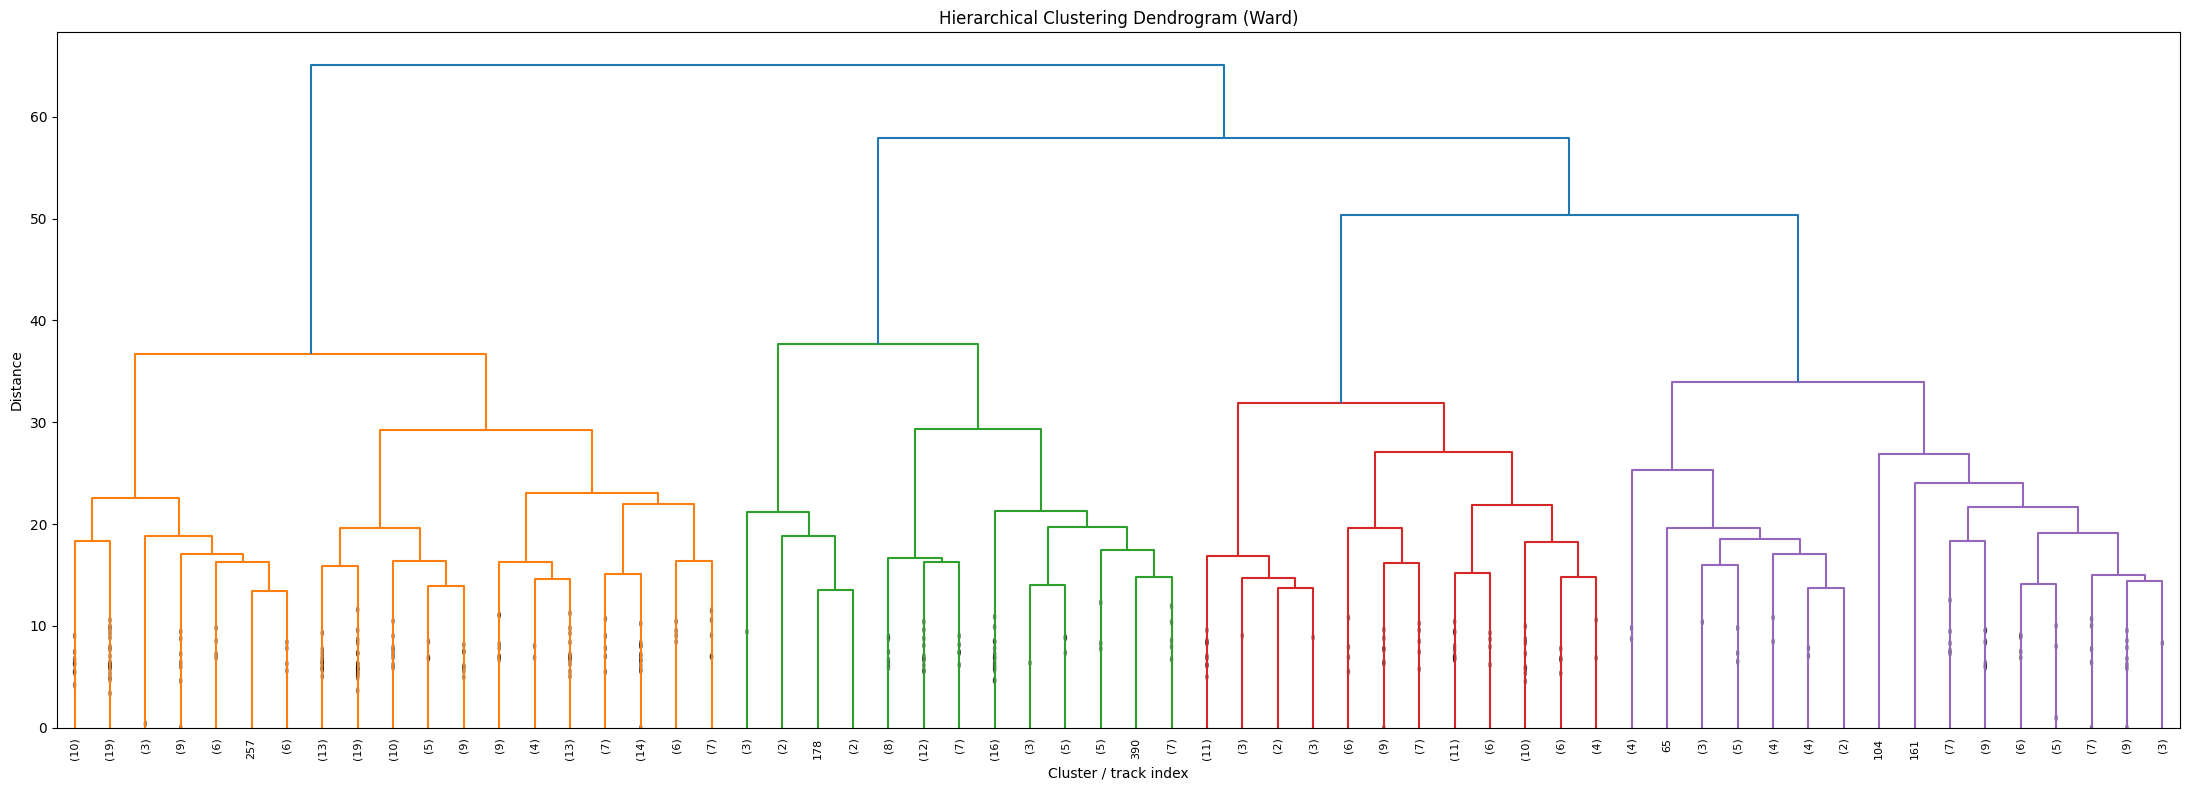


Cluster distribution (k=3):
cluster
0    101
1    123
2    167
Name: count, dtype: int64


In [176]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

n     = len(X_pca)
k_min = 3
k_max = min(10, n // 5)
scores, labels_map = {}, {}

for k in range(k_min, k_max + 1):
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    score  = silhouette_score(X_pca, labels, sample_size=min(n, 2000))
    scores[k]     = score
    labels_map[k] = labels
    print(f'  k={k:2d}  silhouette={score:.4f}')

best_k = max(scores, key=scores.get)
print(f'\nBest k={best_k}  silhouette={scores[best_k]:.4f}')
df_final['cluster'] = labels_map[best_k]

from sklearn.metrics import davies_bouldin_score
best_labels = labels_map[best_k]
dbi = davies_bouldin_score(X_pca, best_labels)
print(f'Davies-Bouldin index (k={best_k}): {dbi:.3f}')

pd.DataFrame({'k': list(scores.keys()),
              'silhouette': list(scores.values())}).to_csv(
    out('silhouette_scores.csv'), index=False)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(list(scores.keys()), list(scores.values()), marker='o', lw=1.5)
ax.axvline(best_k, color='crimson', ls='--', label=f'Best k={best_k}')
ax.set_xlabel('k'); ax.set_ylabel('Silhouette'); ax.legend()
plt.tight_layout()
plt.savefig(out('silhouette.png'), dpi=150)
plt.show()

print('Computing Ward linkage...')
Z = linkage(X_pca, method='ward')
fig2, ax2 = plt.subplots(figsize=(22, 8))
dendrogram(Z, ax=ax2, truncate_mode='lastp', p=min(60, n),
           leaf_rotation=90, leaf_font_size=8, show_contracted=True)
ax2.set_title('Hierarchical Clustering Dendrogram (Ward)')
ax2.set_xlabel('Cluster / track index'); ax2.set_ylabel('Distance')
plt.tight_layout()
plt.savefig(out('dendrogram.png'), dpi=150)
plt.show()

print(f'\nCluster distribution (k={best_k}):')
print(df_final['cluster'].value_counts().sort_index())


---
## Stage 7 — UMAP 2-D embedding

In [177]:
import umap as umap_lib

n_neighbors = max(5, min(15, int(np.sqrt(n))))
print(f'Running UMAP (n_neighbors={n_neighbors}, min_dist=0.05)...')
reducer = umap_lib.UMAP(
    n_components=2, n_neighbors=n_neighbors,
    min_dist=0.1, random_state=42, verbose=False,
)

emb2d            = reducer.fit_transform(X_pca)
df_final['umap_x'] = emb2d[:, 0]
df_final['umap_y'] = emb2d[:, 1]

df_final.to_csv(out('features_final.csv'), index=False)
print(f'Saved → {out("features_final.csv")}  ({len(df_final)} tracks)')


Running UMAP (n_neighbors=15, min_dist=0.05)...
Saved → output/features_final.csv  (391 tracks)


---
## Stage 8 — Interactive UMAP plot

In [178]:
import plotly.graph_objects as go

hover_cols = [c for c in DESCRIPTORS if c in df_final.columns]
COLORS = [
    '#4C9BE8','#E8834C','#4CE8A0','#E84C6B','#A04CE8',
    '#E8D94C','#4CE8D9','#E84CA0','#6BE84C','#4C6BE8',
]

fig = go.Figure()
for idx, cl in enumerate(sorted(df_final['cluster'].unique())):
    sub = df_final[df_final['cluster'] == cl]
    hover_text = [
        '<b>' + r['track_id'] + '</b><br>' +
        (f"🎵 {r['key']} {r.get('camelot','')}  ⏱ {float(r['tempo']):.0f} BPM<br>"
         if 'key' in r.index else '') +
        '<br>'.join(f'{c}: {r[c]:.2f}' for c in hover_cols if c in r.index) +
        (f"<br><i>{r['tags']}</i>"
         if 'tags' in r.index and pd.notna(r.get('tags')) else '')
        for _, r in sub.iterrows()
    ]
    fig.add_trace(go.Scatter(
        x=sub['umap_x'], y=sub['umap_y'], mode='markers',
        name=f'Cluster {cl}',
        marker=dict(size=10, color=COLORS[idx % len(COLORS)],
                    opacity=0.85, line=dict(width=0.5, color='white')),
        text=hover_text, hovertemplate='%{text}<extra></extra>',
    ))

fig.update_layout(
    title='CORS Nebula Map — UMAP coloured by cluster',
    xaxis_title='UMAP 1', yaxis_title='UMAP 2', height=700,
    plot_bgcolor='#0e0e16', paper_bgcolor='#0e0e16',
    font=dict(color='white'),
    xaxis=dict(showgrid=False, zeroline=False),
    yaxis=dict(showgrid=False, zeroline=False),
    legend=dict(itemsizing='constant'),
    hoverlabel=dict(bgcolor='white', font_size=12),
    margin=dict(l=10, r=10, t=50, b=10),
)
# for corpus under 100 tracks use fixed n_neighbors=10
# for larger corpus let it scale with sqrt(n)
n_neighbors = 10 if n < 100 else max(10, min(20, int(np.sqrt(n))))
fig.show()
print('Hover any point → track name, key, BPM, all descriptors, tags.')


Hover any point → track name, key, BPM, all descriptors, tags.


---
## Stage 9 — Annotation tool
## Stage 9 — Annotation tool
Rate each track on 6 perceptual dimensions (0–10), each corresponding directly to one of the system's core semantic descriptors.
Saves to `output/annotations.csv`. Re-run to continue — already-rated tracks are skipped.

| Dimension | Low | High |
|-----------|-----|------|
| brightness | very dark / sub-dominant | very bright / treble-dominant |
| punch | soft rounded kick / no attack | hard compressed kick / aggressive attack |
| tonality | fully atonal / no harmonic content | strongly tonal / clear key centre |
| density | minimal / sparse / lots of space | dense / layered / full frequency range |
| four_four | broken / irregular / absent rhythm | perfectly stable four-on-the-floor |
| groove | rigid / mechanical / quantised | fluid / swinging / physical feel |

In [179]:
import ipywidgets as widgets
from IPython.display import display, Audio, clear_output
import pandas as pd
import numpy as np
from pathlib import Path
import librosa

ANNOT_PATH    = out("annotations.csv")
DIMENSIONS    = ['brightness', 'punch', 'tonality', 'density', 'four_four', 'groove']
PREVIEW_DUR   = 30
PREVIEW_START = 70


DIM_DESCRIPTORS = {
    'brightness' : ['brightness', 'spectral_centroid_mean', 'spectral_spread_mean'],
    'punch'      : ['punch', 'onset_sharpness', 'bass_weight'],
    'tonality'   : ['tonality', 'chroma_entropy', 'chroma_energy'],
    'density'    : ['density', 'rms_mean', 'spectral_flux_mean'],
    'four_four'  : ['groove_regularity', 'ibi_cv', 'rhythm_strength'],
    'groove'     : ['groove_regularity', 'rhythm_strength', 'punch'],
}
DIM_LABELS = {
    'brightness' : '0 = very dark / sub-dominant   →   10 = very bright / treble-dominant',
    'punch'      : '0 = soft rounded kick / no attack   →   10 = hard compressed kick / aggressive attack',
    'tonality'   : '0 = fully atonal / no harmonic content   →   10 = strongly tonal / clear key centre',
    'density'    : '0 = minimal / sparse / lots of space   →   10 = dense / layered / full frequency range',
    'four_four'  : '0 = broken / irregular / absent rhythm   →   10 = perfectly stable four-on-the-floor',
    'groove'     : '0 = rigid / mechanical / quantised   →   10 = fluid / swinging / physical feel',
}


if Path(ANNOT_PATH).exists():
    df_annot      = pd.read_csv(ANNOT_PATH)
    already_rated = set(df_annot['track_id'].tolist())
else:
    df_annot      = pd.DataFrame(columns=['track_id'] + DIMENSIONS)
    already_rated = set()

tracks_to_rate = [
    (row['track_id'], row['filepath'])
    for _, row in df_final.iterrows()
    if row['track_id'] not in already_rated
]
print(f'{len(already_rated)} rated, {len(tracks_to_rate)} remaining.')

if not tracks_to_rate:
    print('All tracks rated!')
else:
    state       = {'idx': 0}
    track_label = widgets.HTML()
    desc_label  = widgets.HTML()
    audio_out   = widgets.Output()
    progress    = widgets.HTML()

    sliders = {
        dim: widgets.IntSlider(
            value=5, min=0, max=10, step=1,
            description=dim.title() + ':',
            style={'description_width': '120px'},
            layout=widgets.Layout(width='500px'),
        )
        for dim in DIMENSIONS
    }
    hints = {
        dim: widgets.HTML(
            value=f'<small style="color:#888;margin-left:130px">{DIM_LABELS[dim]}</small>'
        )
        for dim in DIMENSIONS
    }
    btn_save   = widgets.Button(description='Save & next ▶', button_style='success',
                                layout=widgets.Layout(width='160px', height='40px'))
    btn_skip   = widgets.Button(description='Skip →', button_style='warning',
                                layout=widgets.Layout(width='100px', height='40px'))
    status_out = widgets.Output()

    def get_descriptor_html(track_id):
        row = df_final[df_final['track_id'] == track_id]
        if row.empty: return ''
        row   = row.iloc[0]
        parts = ['<table style="font-size:12px;border-collapse:collapse">',
                 '<tr>'
                 '<th style="padding:2px 12px;text-align:left">Dimension</th>'
                 '<th style="padding:2px 12px;text-align:left">Descriptors</th>'
                 '<th style="padding:2px 12px;text-align:left">Values</th>'
                 '</tr>']
        for dim, descs in DIM_DESCRIPTORS.items():
            vals = []
            for d in descs:
                if d in row.index:
                    v   = row[d]
                    bar = '█' * int(v * 10) if isinstance(v, float) and 0 <= v <= 1 else ''
                    vals.append(f'{d}: {v:.2f} {bar}')
            parts.append(
                f'<tr>'
                f'<td style="padding:2px 12px"><b>{dim}</b></td>'
                f'<td style="padding:2px 12px;color:#555">{", ".join(descs)}</td>'
                f'<td style="padding:2px 12px;font-family:monospace">{"  |  ".join(vals)}</td>'
                f'</tr>'
            )
        parts.append('</table>')
        return ''.join(parts)

    def load_track(idx):
        if idx >= len(tracks_to_rate):
            with status_out:
                clear_output()
                print(f'✅ All done! Saved to {ANNOT_PATH}')
            return
        tid, fp           = tracks_to_rate[idx]
        track_label.value = f'<h3>🎵 {tid}</h3>'
        progress.value    = f'<i>Track {idx+1} of {len(tracks_to_rate)}</i>'
        desc_label.value  = get_descriptor_html(tid)
        for s in sliders.values(): s.value = 5
        audio_out.clear_output()
        try:
            y, sr = librosa.load(fp, sr=22050, mono=True,
                                  offset=PREVIEW_START, duration=PREVIEW_DUR)
            with audio_out: display(Audio(y, rate=sr, autoplay=False))
        except Exception as e:
            with audio_out: print(f'Preview unavailable: {e}')

    def on_save(b):
        global df_annot, already_rated
        idx = state['idx']
        if idx >= len(tracks_to_rate): return
        tid, _  = tracks_to_rate[idx]
        row     = {'track_id': tid, **{d: sliders[d].value for d in DIMENSIONS}}
        df_annot = pd.concat([df_annot, pd.DataFrame([row])], ignore_index=True)
        df_annot.to_csv(ANNOT_PATH, index=False)
        already_rated.add(tid)
        with status_out:
            clear_output(wait=True)
            print(f'✓ {tid}  |  ' + '  '.join(f'{d}={sliders[d].value}' for d in DIMENSIONS))
        state['idx'] += 1
        load_track(state['idx'])

    def on_skip(b):
        with status_out:
            clear_output(wait=True)
            print(f'Skipped: {tracks_to_rate[state["idx"]][0]}')
        state['idx'] += 1
        load_track(state['idx'])

    btn_save.on_click(on_save)
    btn_skip.on_click(on_skip)

    slider_rows = [
        widgets.VBox([sliders[d], hints[d]], layout=widgets.Layout(margin='0 0 6px 0'))
        for d in DIMENSIONS
    ]
    ui = widgets.VBox([
        progress, track_label, audio_out,
        widgets.HTML('<hr><b>Descriptor reference:</b>'),
        desc_label,
        widgets.HTML('<hr><b>Your ratings:</b>'),
        *slider_rows,
        widgets.HBox([btn_save, btn_skip]),
        status_out,
    ])
    display(ui)
    load_track(0)


0 rated, 391 remaining.


---
## Stage 10 — SVR supervised validation
Run after annotating at least 20 tracks.
R² > 0.4 = dimension is acoustically predictable.  Low R² = requires human judgment.

In [180]:
import joblib, os
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from pathlib import Path
import pandas as pd

ANNOT_PATH = out("annotations.csv")
SVR_DIR    = out("svr_models")
os.makedirs(SVR_DIR, exist_ok=True)

if not Path(ANNOT_PATH).exists():
    print('No annotations.csv found — run the annotation tool first.')
else:
    annotations = pd.read_csv(ANNOT_PATH)
    DIMS = ['brightness', 'punch', 'tonality', 'density', 'four_four', 'groove']
    DIMS = [d for d in DIMS if d in annotations.columns]

    rename_map = {d: f'{d}_desc' for d in DIMS if d in df_final.columns}
    merged = df_final.rename(columns=rename_map).merge(
        annotations, on='track_id', how='inner'
    )
    print(f'Annotated tracks available: {len(merged)}')
    print(f'Columns renamed in df_final: {rename_map}')

    if len(merged) < 10:
        print('Need at least 10 annotated tracks. Keep rating!')
    else:
        _NF = set([f'{d}_desc' for d in DIMS] + [
            'track_id', 'filepath', 'actual_window_dur',
            'tags', 'key', 'scale', 'camelot', 'key_strength', 'key_idx', 'bpm_tier',
            'cluster', 'umap_x', 'umap_y',
        ])
        _NF.update([c for c in df_final.columns
                    if c.endswith('_scale') or c.startswith('tag_') or c.startswith('eff_')])

        feat_cols = [c for c in df_final.columns
                     if c not in _NF and df_final[c].dtype.kind in ('f', 'i')]

        # ── BLOCK 1: align features and refit scaler/PCA if needed ──
        feat_cols_svr = [c for c in feat_cols if c in merged.columns]
        if len(feat_cols_svr) != scaler.n_features_in_:
            print(f"Refitting scaler on {len(feat_cols_svr)} features...")
            X_all = df_final[feat_cols_svr].values.astype(float)
            scaler_svr = StandardScaler()
            pca_svr = PCA(n_components=0.95)
            X_sc_all = scaler_svr.fit_transform(X_all)
            X_pc_all = pca_svr.fit_transform(X_sc_all)
            print(f"PCA: {pca_svr.n_components_} components retained")
        else:
            feat_cols_svr = feat_cols
            scaler_svr = scaler
            pca_svr = pca

        # ── BLOCK 2: transform the merged annotated subset ──
        X_merged = merged[feat_cols_svr].values.astype(float)
        if len(feat_cols_svr) != scaler.n_features_in_:
            X_sc = scaler_svr.transform(X_merged)
            X_pc = pca_svr.transform(X_sc)
        else:
            X_sc = scaler.transform(X_merged)
            X_pc = pca.transform(X_sc)

        # ── SVR training and evaluation ──
        print('\nDimension             R²       MAE')
        print('-' * 42)
        metrics = {}
        for dim in DIMS:
            y = merged[dim].values.astype(float)
            X_tr, X_te, y_tr, y_te = train_test_split(
                X_pc, y, test_size=0.2, random_state=42)
            svr = SVR(kernel='linear', C=1.0, epsilon=0.5)
            svr.fit(X_tr, y_tr)
            y_pred = svr.predict(X_te)
            r2  = r2_score(y_te, y_pred)
            mae = mean_absolute_error(y_te, y_pred)
            metrics[dim] = {'r2': round(r2, 3), 'mae': round(mae, 3)}
            print(f'{dim:20s}  {r2:+.3f}   {mae:.3f}')
            joblib.dump(svr, f'{SVR_DIR}/{dim}.joblib')

        pd.DataFrame(metrics).T.to_csv(out("svr_metrics.csv"))
        print(f'\nModels → {SVR_DIR}/')
        print('Tip: R² > 0.4 = good predictability from audio features alone.')

No annotations.csv found — run the annotation tool first.


---
## Summary

In [181]:
import os

print('=' * 55)
print('Pipeline complete.')
print(f'  Tracks processed    : {len(df_final)}')
print(f'  Librosa feat cols   : {len(feature_cols)}')
print(f'  PCA components      : {pca.n_components_}')
print(f'  Optimal k (K-means) : {best_k}')
print(f'  Silhouette score    : {scores[best_k]:.4f}')
print('=' * 55)

FILES = [
    'features.csv', 'essentia_embeddings.csv', 'features_final.csv',
    'distance_matrix.npy', 'scaler.joblib', 'pca.joblib',
    'silhouette.png', 'dendrogram.png', 'pca_variance.png',
    'silhouette_scores.csv', 'annotations.csv', 'svr_metrics.csv',
]
print('\nOutput files:')
for f in FILES:
    path = out(f)
    if os.path.exists(path):
        print(f'  ✓  {f}  ({os.path.getsize(path)/1e3:.1f} KB)')
    else:
        print(f'  -  {f}  (not yet created)')

print(f'\nDescriptors: {", ".join([c for c in DESCRIPTORS if c in df_final.columns])}')
print(f'\nLaunch the tool:  streamlit run app.py')



Pipeline complete.
  Tracks processed    : 391
  Librosa feat cols   : 77
  PCA components      : 43
  Optimal k (K-means) : 3
  Silhouette score    : 0.0913

Output files:
  ✓  features.csv  (638.2 KB)
  ✓  essentia_embeddings.csv  (145.1 KB)
  ✓  features_final.csv  (945.8 KB)
  ✓  distance_matrix.npy  (1223.2 KB)
  ✓  scaler.joblib  (2.4 KB)
  ✓  pca.joblib  (29.1 KB)
  ✓  silhouette.png  (30.4 KB)
  ✓  dendrogram.png  (79.8 KB)
  ✓  pca_variance.png  (32.0 KB)
  ✓  silhouette_scores.csv  (0.2 KB)
  -  annotations.csv  (not yet created)
  -  svr_metrics.csv  (not yet created)

Descriptors: brightness, compactness, density, rhythm_strength, texture, warmth, tonality, punch, bass_weight, groove_regularity

Launch the tool:  streamlit run app.py
